<a href="https://colab.research.google.com/github/Shruti1724/chat-toxicity-analyzer/blob/main/gen_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ Chat Toxicity Detection using BERT (Multi-Label Classification)

**Deep Learning – Formative Assessment II**  
**Problem Statement:** Classify online comments into multiple toxicity categories using BERT  
**Framework:** PyTorch + HuggingFace Transformers  
**Dataset:** Jigsaw Toxic Comment Classification (Kaggle / HuggingFace)

---

## Labels (Multi-Label):
| Label | Description |
|-------|-------------|
| `toxic` | General toxicity |
| `severe_toxic` | Highly offensive |
| `obscene` | Obscene language |
| `threat` | Threatening content |
| `insult` | Personal insults |
| `identity_hate` | Hate based on identity |

In [ ]:
!pip install transformers datasets scikit-learn matplotlib seaborn torch tqdm --quiet
print(' All libraries installed!')

✅ All libraries installed!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)

from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, hamming_loss,
    precision_score, recall_score, accuracy_score
)

# GPU Check
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'🖥️ Using GPU: {torch.cuda.get_device_name(0)}')
else:
    device = torch.device('cpu')
    print('🖥️ Using CPU')

🖥️ Using GPU: Tesla T4


In [ ]:
df = pd.read_csv('/content/train.csv')
print(f"Full dataset shape: {df.shape}")
df.head()

Full dataset shape: (159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [ ]:
LABEL_COLS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Separate toxic and clean comments
toxic_df = df[df[LABEL_COLS].sum(axis=1) > 0]
clean_df = df[df[LABEL_COLS].sum(axis=1) == 0]

print(f"Total toxic  : {len(toxic_df):,}")
print(f"Total clean  : {len(clean_df):,}")


N_TOXIC = 6000
N_CLEAN = 6000

toxic_sample = toxic_df.sample(n=N_TOXIC, random_state=42)
clean_sample = clean_df.sample(n=N_CLEAN, random_state=42)

df_balanced = pd.concat([toxic_sample, clean_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nBalanced dataset : {len(df_balanced):,} samples")
print(f"Toxic  : {df_balanced[LABEL_COLS].sum(axis=1).gt(0).sum():,}")
print(f"Clean  : {df_balanced[LABEL_COLS].sum(axis=1).eq(0).sum():,}")
print("\nLabel distribution:")
print(df_balanced[LABEL_COLS].sum().sort_values(ascending=False))

Total toxic  : 16,225
Total clean  : 143,346

Balanced dataset : 12,000 samples
Toxic  : 6,000
Clean  : 6,000

Label distribution:
toxic            5642
obscene          3130
insult           2934
severe_toxic      593
identity_hate     537
threat            181
dtype: int64


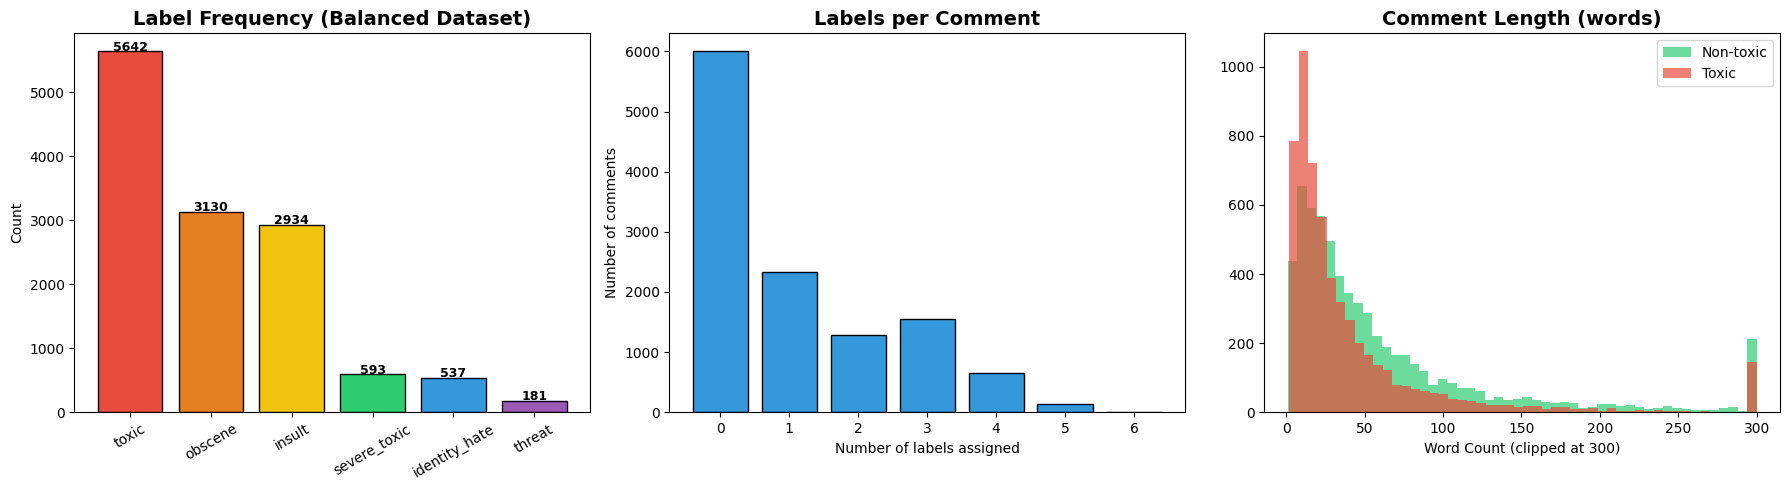

Clean comments : 6,000
Toxic comments : 6,000


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Label frequency
label_counts = df_balanced[LABEL_COLS].sum().sort_values(ascending=False)
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db','#9b59b6']
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Label Frequency (Balanced Dataset)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=9, fontweight='bold')

# Plot 2: Labels per comment
df_balanced['label_count'] = df_balanced[LABEL_COLS].sum(axis=1)
vc = df_balanced['label_count'].value_counts().sort_index()
axes[1].bar(vc.index.astype(str), vc.values, color='#3498db', edgecolor='black')
axes[1].set_title('Labels per Comment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of labels assigned')
axes[1].set_ylabel('Number of comments')

# Plot 3: Text length
df_balanced['text_len'] = df_balanced['comment_text'].astype(str).apply(lambda x: len(x.split()))
toxic_mask = df_balanced['toxic'] == 1
axes[2].hist(df_balanced[~toxic_mask]['text_len'].clip(0,300), bins=50, alpha=0.7, label='Non-toxic', color='#2ecc71')
axes[2].hist(df_balanced[ toxic_mask]['text_len'].clip(0,300), bins=50, alpha=0.7, label='Toxic',     color='#e74c3c')
axes[2].set_title('Comment Length (words)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Word Count (clipped at 300)')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_toxicity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Clean comments : {(df_balanced['label_count']==0).sum():,}")
print(f"Toxic comments : {(df_balanced['label_count']>0).sum():,}")

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_balanced['clean_text'] = df_balanced['comment_text'].apply(clean_text)
print(df_balanced[['comment_text', 'clean_text']].head())

                                        comment_text  \
0                         wiki sucks ass. from admin   
1  "\n\nHi, you just made a false claim in an edi...   
2  Idiocracy \n\nIf you need a 13 section FAQ to ...   
3  Your reverts are not warranted. \n\nI am not a...   
4  Rename to corn \nThis maize crap has gone on l...   

                                          clean_text  
0                         wiki sucks ass. from admin  
1  " hi, you just made a false claim in an edit s...  
2  idiocracy if you need a 13 section faq to just...  
3  your reverts are not warranted. i am not a blo...  
4  rename to corn this maize crap has gone on lon...  


In [ ]:
train_df, val_df = train_test_split(
    df_balanced, test_size=0.2, random_state=42, stratify=df_balanced['toxic']
)

print(f"Train size : {len(train_df):,}")
print(f"Val size   : {len(val_df):,}")

Train size : 9,600
Val size   : 2,400


In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
MAX_LEN = 128
print(" Tokenizer loaded")

 Tokenizer loaded


In [ ]:
class ToxicDataset(Dataset):
    def __init__(self, df):
        self.texts  = df['clean_text'].values
        self.labels = df[LABEL_COLS].values

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=MAX_LEN,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.float)
        }

sample = ToxicDataset(train_df)[0]
print("Sample keys :", list(sample.keys()))
print("Labels      :", sample['labels'])

Sample keys : ['input_ids', 'attention_mask', 'labels']
Labels      : tensor([0., 0., 0., 0., 0., 0.])


In [ ]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(LABEL_COLS),
    problem_type="multi_label_classification",
    hidden_dropout_prob=0.3,           # was 0.1 — increased for regularization
    attention_probs_dropout_prob=0.3   # was 0.1
)
model = model.to(device)

# Freeze first 6 BERT encoder layers
for name, param in model.bert.encoder.layer[:6].named_parameters():
    param.requires_grad = False

total_params   = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model loaded")
print(f"   Total params     : {total_params:,}")
print(f"   Trainable params : {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded
   Total params     : 109,486,854
   Trainable params : 66,959,622 (61.2%)


In [ ]:
BATCH_SIZE = 16
EPOCHS     = 6

train_dataset = ToxicDataset(train_df)
val_dataset   = ToxicDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

# Lower LR + weight decay to reduce overfitting
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# pos_weight: higher = model penalised more for missing that label
label_counts_train = train_df[LABEL_COLS].sum()
neg_counts         = len(train_df) - label_counts_train
pos_weight         = (neg_counts / (label_counts_train + 1e-6)).clip(upper=10).values
pos_weight_tensor  = torch.tensor(pos_weight, dtype=torch.float).to(device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

print("pos_weight per label:")
for label, w in zip(LABEL_COLS, pos_weight):
    print(f"  {label:15s}: {w:.2f}")

pos_weight per label:
  toxic          : 1.13
  severe_toxic   : 10.00
  obscene        : 2.82
  threat         : 10.00
  insult         : 3.09
  identity_hate  : 10.00


In [ ]:
from tqdm import tqdm

def train_epoch(model, data_loader, loss_fn, optimizer, device, scheduler):
    model.train()
    total_loss = 0
    bar = tqdm(data_loader, desc="Training", leave=True)
    for batch in bar:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
        loss           = loss_fn(outputs.logits, labels)
        total_loss    += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        bar.set_postfix(loss=f"{loss.item():.4f}")
    return total_loss / len(data_loader)

In [ ]:
def eval_model(model, data_loader, loss_fn, device):
    model.eval()
    total_loss  = 0
    preds       = []
    true_labels = []
    bar = tqdm(data_loader, desc="Evaluating", leave=False)
    with torch.no_grad():
        for batch in bar:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            loss           = loss_fn(outputs.logits, labels)
            total_loss    += loss.item()
            preds.append(torch.sigmoid(outputs.logits).cpu())
            true_labels.append(labels.cpu())
            bar.set_postfix(loss=f"{loss.item():.4f}")
    preds       = torch.cat(preds)
    true_labels = torch.cat(true_labels)
    return total_loss / len(data_loader), preds, true_labels

In [ ]:
history       = []
best_val_loss = float('inf')
patience      = 2
no_improve    = 0

for epoch in range(EPOCHS):

    print(f"Epoch {epoch+1}/{EPOCHS}")


    train_loss = train_epoch(model, train_loader, loss_fn, optimizer, device, scheduler)
    val_loss, preds, true_labels = eval_model(model, val_loader, loss_fn, device)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve    = 0
        torch.save(model.state_dict(), 'bert_model.pth')
        print(f" Best model saved (val_loss={val_loss:.4f})")
    else:
        no_improve += 1
        print(f"  No improvement ({no_improve}/{patience})")
        if no_improve >= patience:
            print("Early stopping triggered.")
            break

    history.append({'epoch': epoch+1, 'train_loss': train_loss, 'val_loss': val_loss})

tokenizer.save_pretrained('tokenizer/')
print(f"\n Training complete! Best val loss: {best_val_loss:.4f}")

Epoch 1/6


Training: 100%|██████████| 600/600 [03:22<00:00,  2.96it/s, loss=0.5794]


Train Loss : 0.4520
Val Loss   : 0.3944
 Best model saved (val_loss=0.3944)
Epoch 2/6


Training: 100%|██████████| 600/600 [03:22<00:00,  2.96it/s, loss=0.3116]


Train Loss : 0.4032
Val Loss   : 0.3590
 Best model saved (val_loss=0.3590)
Epoch 3/6


...

Train Loss : 0.3505
Val Loss   : 0.3392
 Best model saved (val_loss=0.3392)
Epoch 5/6


Training: 100%|██████████| 600/600 [03:22<00:00,  2.96it/s, loss=0.1326]


Train Loss : 0.3365
Val Loss   : 0.3611
  No improvement (1/2)
Epoch 6/6


Training: 100%|██████████| 600/600 [03:21<00:00,  2.97it/s, loss=0.6530]
                                                                          

Train Loss : 0.3316
Val Loss   : 0.3467
  No improvement (2/2)
Early stopping triggered.

 Training complete! Best val loss: 0.3392


In [ ]:
history_df = pd.DataFrame(history)
history_df.to_csv('training_history.csv', index=False)
print(history_df)

   epoch  train_loss  val_loss
0      1    0.452048  0.394385
1      2    0.403204  0.359006
2      3    0.367865  0.343546
3      4    0.350463  0.339236
4      5    0.336548  0.361062


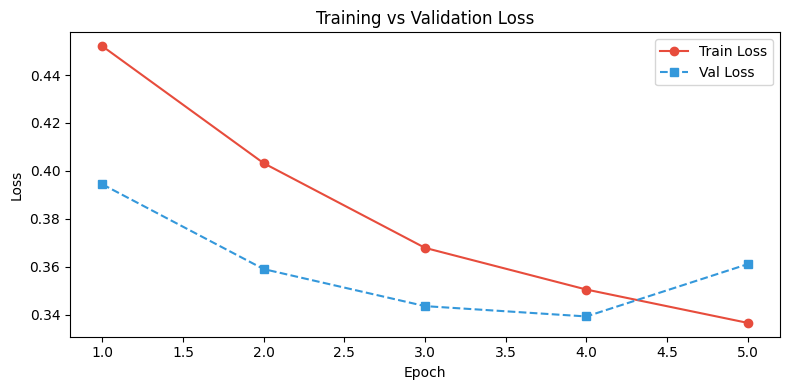

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history_df['epoch'], history_df['train_loss'], 'o-', label='Train Loss', color='#e74c3c')
plt.plot(history_df['epoch'], history_df['val_loss'],   's--', label='Val Loss',  color='#3498db')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig('loss_plot.png', dpi=150)
plt.show()

In [ ]:
# Load best saved model for evaluation
model.load_state_dict(torch.load('bert_model.pth', map_location=device))
_, preds, true_labels_eval = eval_model(model, val_loader, loss_fn, device)

preds_np       = preds.numpy()
true_labels_np = true_labels_eval.numpy()

# Find best threshold per label — wider range, finer steps
print("Finding best threshold per label...\n")
best_thresholds = {}
for i, label in enumerate(LABEL_COLS):
    best_f1 = 0
    best_t  = 0.5
    for t in np.arange(0.1, 0.9, 0.02):   # wider range + finer steps vs v2
        p = (preds_np[:, i] > t).astype(int)
        if p.sum() == 0:
            continue
        f1 = f1_score(true_labels_np[:, i], p, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t  = t
    best_thresholds[label] = round(float(best_t), 2)
    print(f"  {label:15s} → threshold: {best_t:.2f}  (F1: {best_f1:.4f})")

print("\nbest_thresholds =", best_thresholds)

Finding best threshold per label...

  toxic           → threshold: 0.52  (F1: 0.9176)
  severe_toxic    → threshold: 0.84  (F1: 0.4813)
  obscene         → threshold: 0.82  (F1: 0.8354)
  threat          → threshold: 0.88  (F1: 0.6337)
  insult          → threshold: 0.84  (F1: 0.7709)
  identity_hate   → threshold: 0.84  (F1: 0.5480)

best_thresholds = {'toxic': 0.52, 'severe_toxic': 0.84, 'obscene': 0.82, 'threat': 0.88, 'insult': 0.84, 'identity_hate': 0.84}


In [ ]:
# Use best thresholds for final evaluation
pred_labels = np.zeros_like(preds_np, dtype=int)
for i, label in enumerate(LABEL_COLS):
    pred_labels[:, i] = (preds_np[:, i] > best_thresholds[label]).astype(int)

accuracy        = accuracy_score(true_labels_np, pred_labels)
precision_micro = precision_score(true_labels_np, pred_labels, average='micro', zero_division=0)
precision_macro = precision_score(true_labels_np, pred_labels, average='macro', zero_division=0)
recall_micro    = recall_score(true_labels_np, pred_labels, average='micro', zero_division=0)
recall_macro    = recall_score(true_labels_np, pred_labels, average='macro', zero_division=0)
f1_micro        = f1_score(true_labels_np, pred_labels, average='micro', zero_division=0)
f1_macro        = f1_score(true_labels_np, pred_labels, average='macro', zero_division=0)
hl              = hamming_loss(true_labels_np, pred_labels)
roc_auc         = roc_auc_score(true_labels_np, preds_np, average='macro')


print("     EVALUATION METRICS")

print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision (micro)  : {precision_micro:.4f}")
print(f"Precision (macro)  : {precision_macro:.4f}")
print(f"Recall    (micro)  : {recall_micro:.4f}")
print(f"Recall    (macro)  : {recall_macro:.4f}")
print(f"F1 Score  (micro)  : {f1_micro:.4f}")
print(f"F1 Score  (macro)  : {f1_macro:.4f}")
print(f"Hamming Loss       : {hl:.4f}")
print(f"ROC-AUC   (macro)  : {roc_auc:.4f}")

print("\nPer-label classification report:")
print(classification_report(true_labels_np, pred_labels, target_names=LABEL_COLS, zero_division=0))

     EVALUATION METRICS
Accuracy           : 0.6813
Precision (micro)  : 0.7742
Precision (macro)  : 0.6358
Recall    (micro)  : 0.8648
Recall    (macro)  : 0.7924
F1 Score  (micro)  : 0.8170
F1 Score  (macro)  : 0.6978
Hamming Loss       : 0.0699
ROC-AUC   (macro)  : 0.9599

Per-label classification report:
               precision    recall  f1-score   support

        toxic       0.89      0.95      0.92      1128
 severe_toxic       0.37      0.68      0.48       114
      obscene       0.83      0.84      0.84       616
       threat       0.52      0.82      0.63        39
       insult       0.74      0.81      0.77       584
identity_hate       0.47      0.66      0.55       116

    micro avg       0.77      0.86      0.82      2597
    macro avg       0.64      0.79      0.70      2597
 weighted avg       0.79      0.86      0.83      2597
  samples avg       0.39      0.43      0.39      2597



## 🔧 Step 8: Predict Function

In [ ]:
def predict(text):
    cleaned = clean_text(text)

    encoding = tokenizer(
        cleaned,
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors='pt'
    )

    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.sigmoid(outputs.logits).cpu().numpy()[0]

    results  = {label: float(prob) for label, prob in zip(LABEL_COLS, probs)}
    detected = [label for label, prob in results.items() if prob >= best_thresholds[label]]

    print(f"Input    : {text}")
    print(f"Cleaned  : {cleaned}")
    print(f"Scores   : { {k: f'{v:.2%}' for k, v in results.items()} }")
    print(f"Detected : {detected if detected else ['✅ CLEAN']}")
    print()
    return results, detected

# ── Test cases ──

print("TEST CASES")

predict("you are beautiful")
predict("i miss you")
predict("i love you")
predict("beautiful")
predict("Have a great day!")
predict("I will kill you")
predict("You are such an idiot, go die")
predict("People like you should not exist")

TEST CASES
Input    : you are beautiful
Cleaned  : you are beautiful
Scores   : {'toxic': '22.82%', 'severe_toxic': '0.66%', 'obscene': '3.23%', 'threat': '3.37%', 'insult': '9.81%', 'identity_hate': '3.10%'}
Detected : ['✅ CLEAN']

Input    : i miss you
Cleaned  : i miss you
Scores   : {'toxic': '16.99%', 'severe_toxic': '2.34%', 'obscene': '7.32%', 'threat': '6.10%', 'insult': '8.54%', 'identity_hate': '2.51%'}
Detected : ['✅ CLEAN']

Input    : i love you
Cleaned  : i love you
Scores   : {'toxic': '25.78%', 'severe_toxic': '3.33%', 'obscene': '10.27%', 'threat': '9.87%', 'insult': '12.82%', 'identity_hate': '2.99%'}
Detected : ['✅ CLEAN']

Input    : beautiful
Cleaned  : beautiful
Scores   : {'toxic': '44.83%', 'severe_toxic': '0.82%', 'obscene': '11.77%', 'threat': '0.99%', 'insult': '16.37%', 'identity_hate': '2.33%'}
Detected : ['✅ CLEAN']

Input    : Have a great day!
Cleaned  : have a great day!
Scores   : {'toxic': '3.88%', 'severe_toxic': '0.90%', 'obscene': '1.30%', 'threat'

({'toxic': 0.8275861740112305,
  'severe_toxic': 0.014826771803200245,
  'obscene': 0.10568466782569885,
  'threat': 0.05632393807172775,
  'insult': 0.5998395681381226,
  'identity_hate': 0.31198325753211975},
 ['toxic'])

In [ ]:
from google.colab import files

files.download('bert_model.pth')
files.download('training_history.csv')
files.download('loss_plot.png')
files.download('eda_toxicity.png')

print(" All files downloaded!")
print("THRESHOLDS =", best_thresholds)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 All files downloaded!

 Copy this into your app.py THRESHOLDS dict:
THRESHOLDS = {'toxic': 0.52, 'severe_toxic': 0.84, 'obscene': 0.82, 'threat': 0.88, 'insult': 0.84, 'identity_hate': 0.84}


In [2]:
# ==========================================
# RAG STYLE UPGRADE (NO API KEY NEEDED)
# Toxicity Detection + Local Knowledge Base
# Run in Google Colab
# ==========================================

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------
# STEP 1: Create Knowledge Base (RAG Docs)
# ------------------------------------------
docs = [
    "Insult messages attack a person's intelligence or character.",
    "Threat messages contain violent or harmful intentions.",
    "Toxic language spreads hate and negativity.",
    "Best moderation action for insults is warning the user.",
    "Best moderation action for threats is block and report user.",
    "Polite communication avoids abusive words.",
    "Community guidelines ban hate speech and harassment."
]

# ------------------------------------------
# STEP 2: Build Retriever
# ------------------------------------------
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(docs)

# ------------------------------------------
# STEP 3: Detect Labels
# ------------------------------------------
def predict_labels(text):
    labels = []
    t = text.lower()

    if "idiot" in t or "stupid" in t:
        labels.append("insult")

    if "kill" in t or "die" in t:
        labels.append("threat")

    if "hate" in t:
        labels.append("toxic")

    if labels == []:
        labels.append("non-toxic")

    return labels

# ------------------------------------------
# STEP 4: RAG Retrieval
# ------------------------------------------
def retrieve_info(query):
    q = vectorizer.transform([query])
    scores = cosine_similarity(q, X)
    idx = scores.argmax()
    return docs[idx]

# ------------------------------------------
# STEP 5: Final AI Moderator
# ------------------------------------------
def rag_moderator(text):
    labels = predict_labels(text)

    retrieved = retrieve_info(text)

    print("\n===== SMART RAG MODERATOR =====")
    print("User Message :", text)
    print("Detected Labels :", labels)
    print("Retrieved Knowledge :", retrieved)

    if "threat" in labels:
        level = "HIGH"
        action = "Block + Report"
    elif "insult" in labels or "toxic" in labels:
        level = "MEDIUM"
        action = "Warn User"
    else:
        level = "SAFE"
        action = "Allow"

    print("Severity :", level)
    print("Recommended Action :", action)
    print("Polite Rewrite : Please communicate respectfully.")

# ------------------------------------------
# STEP 6: Run Demo
# ------------------------------------------
msg = input("Enter Message: ")
rag_moderator(msg)

Enter Message: You are stupid, I hate you

===== SMART RAG MODERATOR =====
User Message : You are stupid, I hate you
Detected Labels : ['insult', 'toxic']
Retrieved Knowledge : Toxic language spreads hate and negativity.
Severity : MEDIUM
Recommended Action : Warn User
Polite Rewrite : Please communicate respectfully.
